# SSC0964 — Introdução à Computação no Mercado Financeiro
## Trabalho 1 — 4 Modelos de Fatores para Seleção de Portfólios

**1º Semestre 2026 — Prof. Denis Fernando Wolf**

**Autores:**
- Felipe Corerato — NUSP 14569800
- Ana Lívia de Magalhães Garbin — NUSP 14557394

---

### Visão geral

Este trabalho implementa **4 modelos de fatores** para seleção de portfólios de ações, cada um combinando **pelo menos 2 fatores** e selecionando **20 ações** em carteira, conforme exigido pelo enunciado. Os objetivos dos quatro modelos são:

1. **Modelo 1 — Maior retorno**
2. **Modelo 2 — Maior relação retorno/volatilidade**
3. **Modelo 3 — Maior alpha**
4. **Modelo 4 — Menor volatilidade**

Para cada modelo reportamos as métricas exigidas (retorno anualizado, volatilidade anualizada, relação retorno/volatilidade, drawdown, alpha e beta) e os gráficos pedidos (retorno acumulado com média móvel de 60 meses, volatilidade anualizada e drawdown). Ao final, há os comentários sobre o processo de rankeamento e seleção, sobre a escolha dos fatores e uma conclusão pessoal sobre os resultados.

### Universo e dados

Trabalhamos com as ações do **S&P 500**, com preços mensais ajustados obtidos do `yfinance`, no período de **janeiro de 2009 a dezembro de 2025**. O panel `dados_sp500.csv` é gerado localmente pelo script `build_dataset.py` que acompanha esta entrega, eliminando dependência de arquivos externos. Os fatores utilizados são todos **derivados de preço** (momentum, volatilidade, momentum ajustado a risco, Sharpe rolante, drawdown rolante e beta rolante), garantindo séries de alta qualidade e ausentes de look-ahead bias.

### Metodologia

A cada mês:
1. Ranqueamos todas as ações elegíveis em cada fator individualmente, respeitando a direção do sinal (ex.: maior `Mom12` é melhor, menor `Volat12` é melhor).
2. Somamos os rankings de cada ação ao longo dos fatores do modelo.
3. Selecionamos as **20 ações** com melhor ranking combinado para compor a carteira do mês.
4. O retorno do portfólio é a média simples dos retornos das 20 ações, descontado o custo de transação de 0,06% por rebalanceamento.

Alpha e beta são calculados via regressão CAPM dos retornos mensais do portfólio contra os retornos do benchmark (S&P 500).


## 0. Setup (Google Colab / execução remota)

A célula abaixo baixa os CSVs do panel diretamente do GitHub se eles não estiverem presentes no diretório de trabalho. **Se você estiver rodando localmente (já com os CSVs ao lado do notebook), ela é um no-op.**

In [1]:
import os, urllib.request

RAW = 'https://github.com/FelipeCorerato/SSC0964/raw/main/projeto-1'
for f in ['dados_sp500.csv', 'indices_sp500.csv']:
    if not os.path.exists(f):
        print(f'baixando {f}...')
        urllib.request.urlretrieve(f'{RAW}/{f}', f)
print('CSVs prontos:', [f for f in ['dados_sp500.csv', 'indices_sp500.csv'] if os.path.exists(f)])

CSVs prontos: ['dados_sp500.csv', 'indices_sp500.csv']


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos dados

O panel `dados_sp500.csv` contém, para cada par (mês, ação), o retorno mensal e os fatores rolantes calculados a partir dos preços históricos. O arquivo `indices_sp500.csv` traz a série de fechamentos mensais do **S&P 500** usado como benchmark. Ambos são gerados pelo script `build_dataset.py` que acompanha esta entrega.

In [3]:
start = '1/2011'
end   = '12/2025'

COST_TRANS = 0.0006

ASCENDING_DIC = {
    'Mom12':    False,
    'Mom6':     False,
    'Volat12':  True,
    'Volat6':   True,
    'MTUM12':   False,
    'MTUM6':    False,
    'Sharpe12': False,
    'MaxDD12':  False,
    'Beta12':   True,
}

dados = pd.read_csv('dados_sp500.csv')
indices_acc = pd.read_csv('indices_sp500.csv')
indices_acc.set_index('Data', inplace=True)
indices = indices_acc.pct_change(fill_method=None)

print(f'Registros no panel:   {len(dados):,}')
print(f'Tickers unicos:       {dados["Ticker"].nunique()}')
print(f'Periodo do backtest:  {start} a {end}')
print(f'\nPrevia do panel (5 linhas com fatores ja calculados):')
dados.dropna().head()

Registros no panel:   101,796
Tickers unicos:       499
Periodo do backtest:  1/2011 a 12/2025

Previa do panel (5 linhas com fatores ja calculados):


,Data,Ticker,IBX,Retorno,Mom12,Mom6,Volat12,Volat6,MTUM12,MTUM6,Sharpe12,MaxDD12,Beta12
6487,Feb-2010,A,1,0.122369,0.550332,0.207149,0.129491,0.114751,4.249974,1.805205,0.349541,-0.111032,1.959333
6488,Feb-2010,AAPL,1,0.065396,1.130922,0.175470,0.080478,0.064672,14.052630,2.713218,0.843512,-0.088596,1.130749
6491,Feb-2010,ABT,1,0.032800,-0.012836,0.196737,0.075888,0.047958,-0.169144,4.102310,0.021752,-0.122642,0.381077
6492,Feb-2010,ACGL,1,0.034107,0.189360,0.150346,0.046145,0.020688,4.103559,7.267146,0.337142,-0.016615,0.603762
6493,Feb-2010,ACN,1,-0.024884,0.323986,0.191474,0.073457,0.078495,4.410527,2.439305,0.354784,-0.059025,0.472633


## 2. Funções auxiliares

As funções `calcular_metricas` e `plotar_modelo` encapsulam, respectivamente, o cálculo de todas as métricas exigidas pelo enunciado (retorno acumulado e anualizado, volatilidade anualizada, relação retorno/volatilidade, drawdown, alpha e beta via regressão CAPM) e a geração dos 4 gráficos pedidos (retorno acumulado, média móvel de 60 meses, volatilidade anualizada e drawdown).

In [4]:
def calc_dif_dates(start, end):
    data_dif = relativedelta(
        datetime.strptime(end, '%m/%Y'),
        datetime.strptime(start, '%m/%Y'),
    )
    return data_dif.years + data_dif.months / 12


def calcular_metricas(Port, nome_modelo, verbose=True):
    anos = calc_dif_dates(start, end)

    ret_acc  = Port['Ret_acc'].iloc[-1] * 100
    vol_aa   = Port['Ret'].std() * (12 ** 0.5) * 100
    ret_aa   = (pow(ret_acc / 100 + 1, 1 / anos) - 1) * 100
    ret_vol  = ret_aa / vol_aa if vol_aa else np.nan
    drawdown = Port['drawdown'].min() * 100

    ref_ret_acc = Port['Ref_acc'].iloc[-1] * 100
    ref_vol_aa  = Port['Ref'].std() * (12 ** 0.5) * 100
    ref_ret_aa  = (pow(ref_ret_acc / 100 + 1, 1 / anos) - 1) * 100

    model = sm.OLS(
        Port['Ret'].to_list(),
        sm.add_constant(Port['Ref'].to_list()),
        missing='drop',
    ).fit()
    alpha = model.params[0] * 12 * 100
    beta  = model.params[1]
    pval_alpha = model.pvalues[0]
    pval_beta  = model.pvalues[1]

    if verbose:
        print(f"\n{'=' * 64}")
        print(f"  {nome_modelo}")
        print(f"{'=' * 64}")
        print(f"  Retorno Acumulado:        {ret_acc:>8.2f}%")
        print(f"  Retorno Anualizado:       {ret_aa:>8.2f}%")
        print(f"  Volatilidade Anualizada:  {vol_aa:>8.2f}%")
        print(f"  Retorno / Volatilidade:   {ret_vol:>8.3f}")
        print(f"  Drawdown Maximo:          {drawdown:>8.2f}%")
        print(f"  Alpha (aa):               {alpha:>8.2f}%   p-value: {pval_alpha:.3f}")
        print(f"  Beta:                     {beta:>8.2f}    p-value: {pval_beta:.3f}")
        print(f"  --- Referencia (S&P 500) ---")
        print(f"  Retorno Anual Ref.:       {ref_ret_aa:>8.2f}%")
        print(f"  Vol. Anual Ref.:          {ref_vol_aa:>8.2f}%")

    return {
        'Modelo':           nome_modelo,
        'Ret Acc (%)':      round(ret_acc, 2),
        'Ret Anual (%)':    round(ret_aa, 2),
        'Vol Anual (%)':    round(vol_aa, 2),
        'Ret/Vol':          round(ret_vol, 3),
        'Drawdown (%)':     round(drawdown, 2),
        'Alpha Anual (%)':  round(alpha, 2),
        'Beta':             round(beta, 2),
    }


def plotar_modelo(Port, nome_modelo, cor='steelblue'):
    Port_acc = pd.DataFrame({
        'Portfolio': Port['Ret_acc'],
        'S&P 500':   Port['Ref_acc'],
    })
    Port_ret = pd.DataFrame({
        'Portfolio': Port['Ret'],
        'S&P 500':   Port['Ref'],
    })

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(nome_modelo, fontsize=14, fontweight='bold', y=1.01)

    ax = axes[0, 0]
    (Port_acc * 100).plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Retorno Acumulado (%)')
    ax.set_xlabel(''); ax.grid(True); ax.legend()

    ax = axes[0, 1]
    med_movel = 60
    Port_mm = ((1 + Port_acc) / (1 + Port_acc.shift(med_movel)) - 1) * 100
    Port_mm.iloc[24:].plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Media Movel 60 Meses (%)')
    ax.set_xlabel(''); ax.grid(True); ax.legend()

    ax = axes[1, 0]
    Port_vol = (1 + Port_ret).rolling(12).std() * (12 ** 0.5) * 100
    Port_vol.plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Volatilidade Anualizada - janela 12m (%)')
    ax.set_xlabel(''); ax.grid(True); ax.legend()

    ax = axes[1, 1]
    Port_acc_max  = Port_acc.cummax()
    Port_drawdown = (((1 + Port_acc) / (1 + Port_acc_max)) - 1) * 100
    Port_drawdown.plot(ax=ax, color=[cor, 'gray'])
    ax.set_title('Drawdown (%)')
    ax.set_xlabel(''); ax.grid(True); ax.legend()

    plt.tight_layout()
    plt.show()

## 3. Função principal — construção do portfólio multifator

A função `create_port_multifator` aceita uma **lista** de fatores (no mínimo 2, conforme exigido pelo enunciado), rankeia cada fator individualmente respeitando a direção desejada (`ASCENDING_DIC`), soma os rankings e seleciona as **20 ações** com melhor ranking combinado a cada mês. O custo de transação por rebalanceamento mensal é de 0,06%.

In [5]:
def create_port_multifator(fatores, filtro_fim, dados, referencia, nome='Portfolio'):
    """Constroi portfolio multifator por soma de rankings.

    Parametros
    ----------
    fatores    : lista de str - fatores a combinar (>=2)
    filtro_fim : int          - numero de acoes selecionadas (top N do ranking)
    dados      : DataFrame    - panel de fatores (colunas: Data, Ticker, IBX, Retorno, fatores)
    referencia : Series       - retornos mensais do benchmark
    nome       : str          - nome descritivo do modelo (apenas log)
    """
    list_date, list_ret = [], []

    for dt in pd.date_range(start=start, end=end, freq='ME').strftime('%b-%Y'):
        cart = dados.loc[
            (dados['Data'] == dt) &
            (dados['IBX'] > 0) &
            (dados['Retorno'].notna())
        ].copy()

        if cart.empty:
            list_date.append(dt)
            list_ret.append(np.nan)
            continue

        rank_sum = pd.Series(0.0, index=cart.index)
        for fator in fatores:
            cart[f'rank_{fator}'] = cart[fator].rank(ascending=ASCENDING_DIC[fator])
            rank_sum = rank_sum + cart[f'rank_{fator}']

        cart['rank_final'] = rank_sum.rank(ascending=True)
        selecao = cart.loc[cart['rank_final'] <= filtro_fim]
        ret = selecao['Retorno'].mean() - COST_TRANS

        list_date.append(dt)
        list_ret.append(ret)

    Port = pd.DataFrame({'Data': list_date, 'Ret': list_ret})
    Port.set_index('Data', inplace=True)

    Port['Ret_acc']  = (1 + Port['Ret']).cumprod() - 1
    Port['acc_max']  = Port['Ret_acc'].cummax()
    Port['drawdown'] = ((1 + Port['Ret_acc']) / (1 + Port['acc_max'])) - 1

    Port['Ref']     = referencia.reindex(Port.index)
    Port['Ref_acc'] = (1 + Port['Ref']).cumprod() - 1

    print(f'  [{nome}] portfolio construido: {Port.dropna(subset=["Ret"]).shape[0]} meses')
    return Port.copy()

## 4. Modelo 1 — Maior Retorno

**Fatores: `Mom12` + `Mom6` + `Volat6` (baixo)**

### Justificativa

O objetivo é capturar o maior retorno absoluto possível. A literatura clássica de momentum (Jegadeesh & Titman, 1993) mostra que ações vencedoras nos últimos 12 meses tendem a continuar performando bem no curto prazo. Para reforçar essa convicção e evitar falsas tendências, exigimos confirmação em uma janela mais curta (`Mom6`): a ação precisa ter sido vencedora **tanto nos últimos 12 quanto nos últimos 6 meses**.

O terceiro filtro (`Volat6` baixo) atua como freio de segurança: dentro do universo de vencedores recentes, excluímos os que ficaram com volatilidade extrema — tipicamente ações que viraram aposta especulativa. Isso preserva a qualidade do sinal de momentum e reduz o risco de pegar topos de bolha.

  [Modelo 1 - Maior Retorno] portfolio construido: 179 meses

  Modelo 1 - Maior Retorno (Mom12 + Mom6 + Volat6)
  Retorno Acumulado:          827.87%
  Retorno Anualizado:          16.11%
  Volatilidade Anualizada:     14.67%
  Retorno / Volatilidade:      1.098
  Drawdown Maximo:            -19.55%
  Alpha (aa):                   6.19%   p-value: 0.015
  Beta:                         0.80    p-value: 0.000
  --- Referencia (S&P 500) ---
  Retorno Anual Ref.:          12.03%
  Vol. Anual Ref.:             14.07%


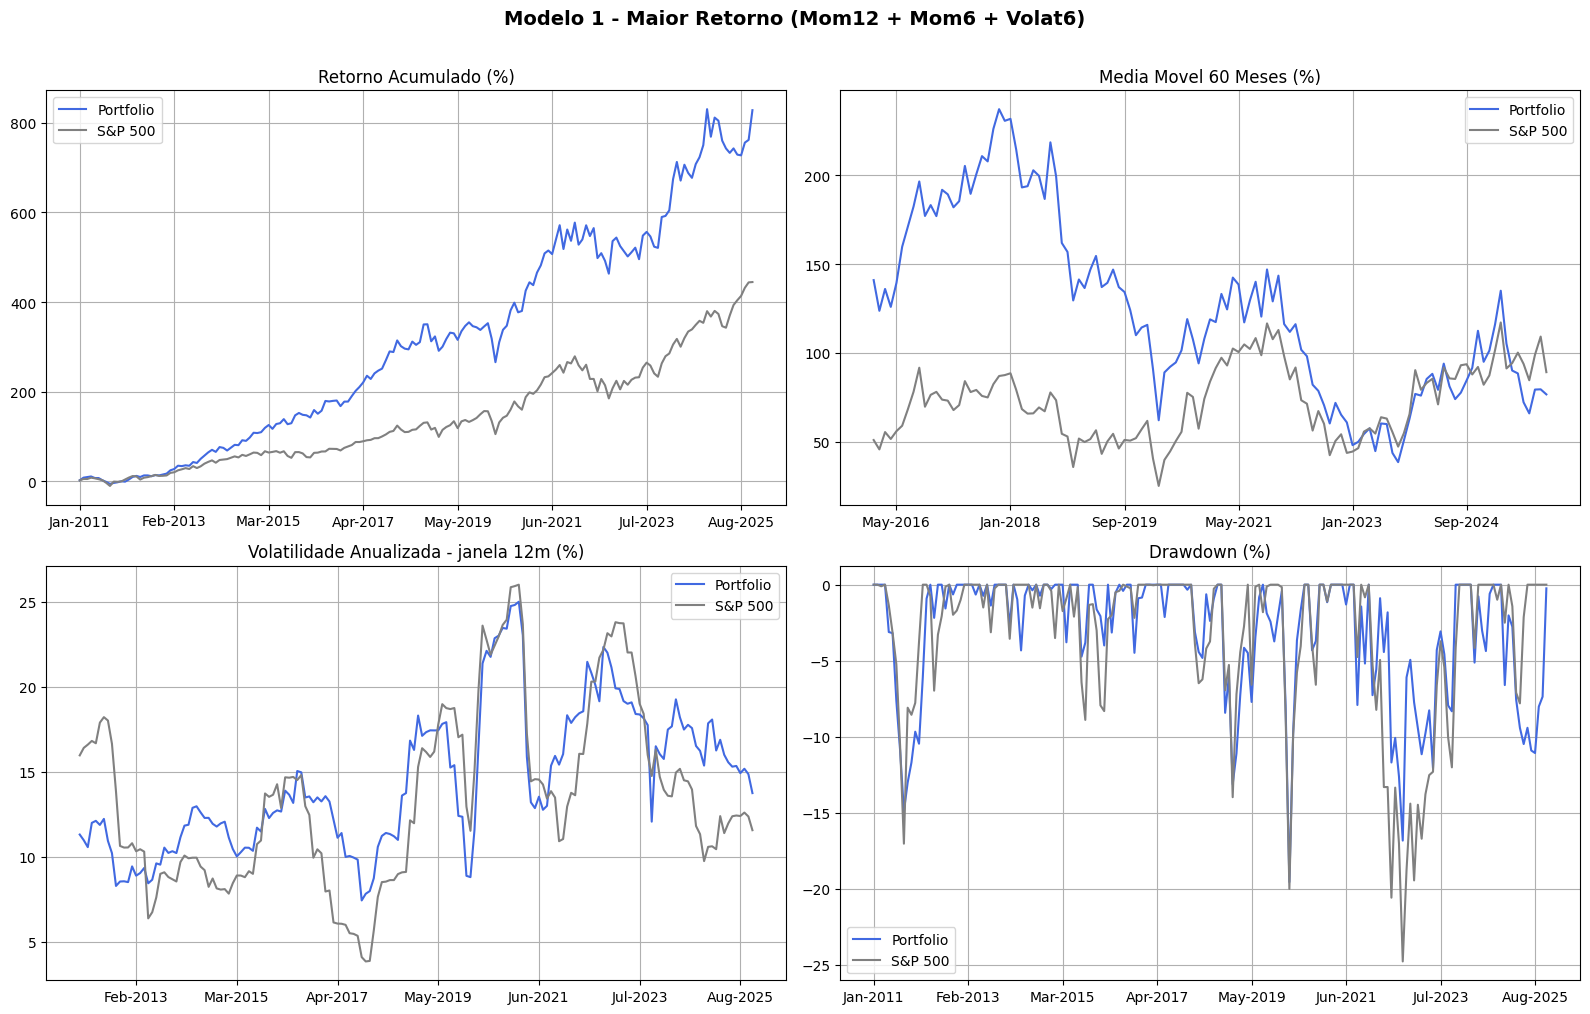

In [6]:
Port1 = create_port_multifator(
    fatores=['Mom12', 'Mom6', 'Volat6'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['SP500'],
    nome='Modelo 1 - Maior Retorno',
)

metricas1 = calcular_metricas(Port1, 'Modelo 1 - Maior Retorno (Mom12 + Mom6 + Volat6)')
plotar_modelo(Port1, 'Modelo 1 - Maior Retorno (Mom12 + Mom6 + Volat6)', cor='royalblue')

## 5. Modelo 2 — Maior Retorno / Volatilidade

**Fatores: `Sharpe12` + `MTUM12` + `Volat12` (baixo)**

### Justificativa

O objetivo é maximizar diretamente a razão retorno/volatilidade. A escolha dos três fatores é deliberadamente complementar:

- `Sharpe12` ranqueia diretamente o que queremos otimizar (retorno médio / vol em 12 meses).
- `MTUM12` (definido como `Mom12 / Volat12`) é o **momentum ajustado a risco** padrão da MSCI — reforça o sinal de qualidade do retorno.
- `Volat12` baixo é o filtro defensivo: mesmo com Sharpe alto, vetamos ações que oscilam demais.

Os três fatores convergem para o mesmo objetivo a partir de ângulos diferentes (numerador, ratio risk-adjusted e denominador), com o intuito de tornar o sinal mais robusto.

  [Modelo 2 - Maior Sharpe] portfolio construido: 179 meses

  Modelo 2 - Maior Sharpe (Sharpe12 + MTUM12 + Volat12)
  Retorno Acumulado:          401.42%
  Retorno Anualizado:          11.41%
  Volatilidade Anualizada:     13.66%
  Retorno / Volatilidade:      0.835
  Drawdown Maximo:            -22.36%
  Alpha (aa):                   2.93%   p-value: 0.239
  Beta:                         0.71    p-value: 0.000
  --- Referencia (S&P 500) ---
  Retorno Anual Ref.:          12.03%
  Vol. Anual Ref.:             14.07%


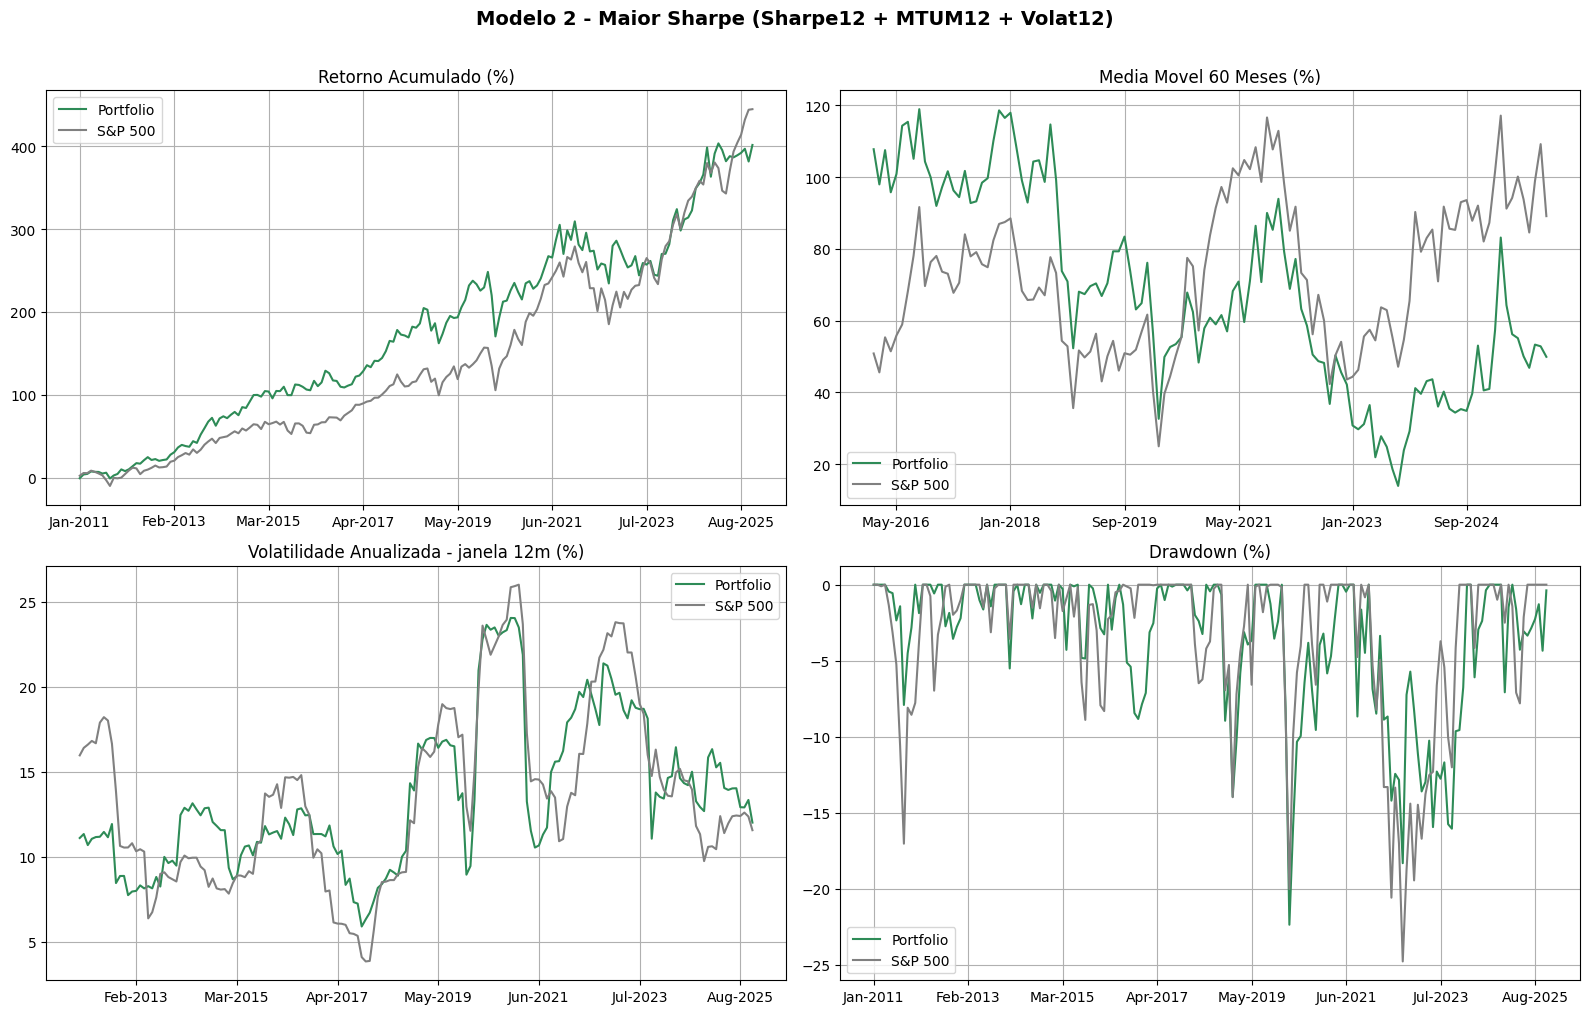

In [7]:
Port2 = create_port_multifator(
    fatores=['Sharpe12', 'MTUM12', 'Volat12'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['SP500'],
    nome='Modelo 2 - Maior Sharpe',
)

metricas2 = calcular_metricas(Port2, 'Modelo 2 - Maior Sharpe (Sharpe12 + MTUM12 + Volat12)')
plotar_modelo(Port2, 'Modelo 2 - Maior Sharpe (Sharpe12 + MTUM12 + Volat12)', cor='seagreen')

## 6. Modelo 3 — Maior Alpha

**Fatores: `Mom12` + `Beta12` (baixo) + `MaxDD12` (baixo)**

### Justificativa

Alpha, no modelo CAPM, é a parcela do retorno **não explicada pelo benchmark**. Para maximizá-lo precisamos de dois ingredientes simultâneos: uma fonte de retorno positivo e baixa correlação com o índice.

- `Mom12`: sinal de retorno positivo persistente.
- `Beta12` baixo: ações com pouca exposição ao mercado — qualquer retorno extra que tragam será classificado como alpha (intercepto) na regressão CAPM, não como prêmio de mercado.
- `MaxDD12` baixo: filtro de qualidade. Empresas que evitaram crashes históricos são tipicamente mais defensivas e estáveis, reforçando a robustez do alpha out-of-sample.

É uma abordagem puramente quantitativa que ataca o alpha pela sua definição estatística (intercepto da regressão), em vez de tentar proxiar qualidade fundamentalista.

  [Modelo 3 - Maior Alpha] portfolio construido: 179 meses

  Modelo 3 - Maior Alpha (Mom12 + Beta12 + MaxDD12)
  Retorno Acumulado:          781.42%
  Retorno Anualizado:          15.71%
  Volatilidade Anualizada:     15.24%
  Retorno / Volatilidade:      1.030
  Drawdown Maximo:            -17.57%
  Alpha (aa):                   6.72%   p-value: 0.027
  Beta:                         0.73    p-value: 0.000
  --- Referencia (S&P 500) ---
  Retorno Anual Ref.:          12.03%
  Vol. Anual Ref.:             14.07%


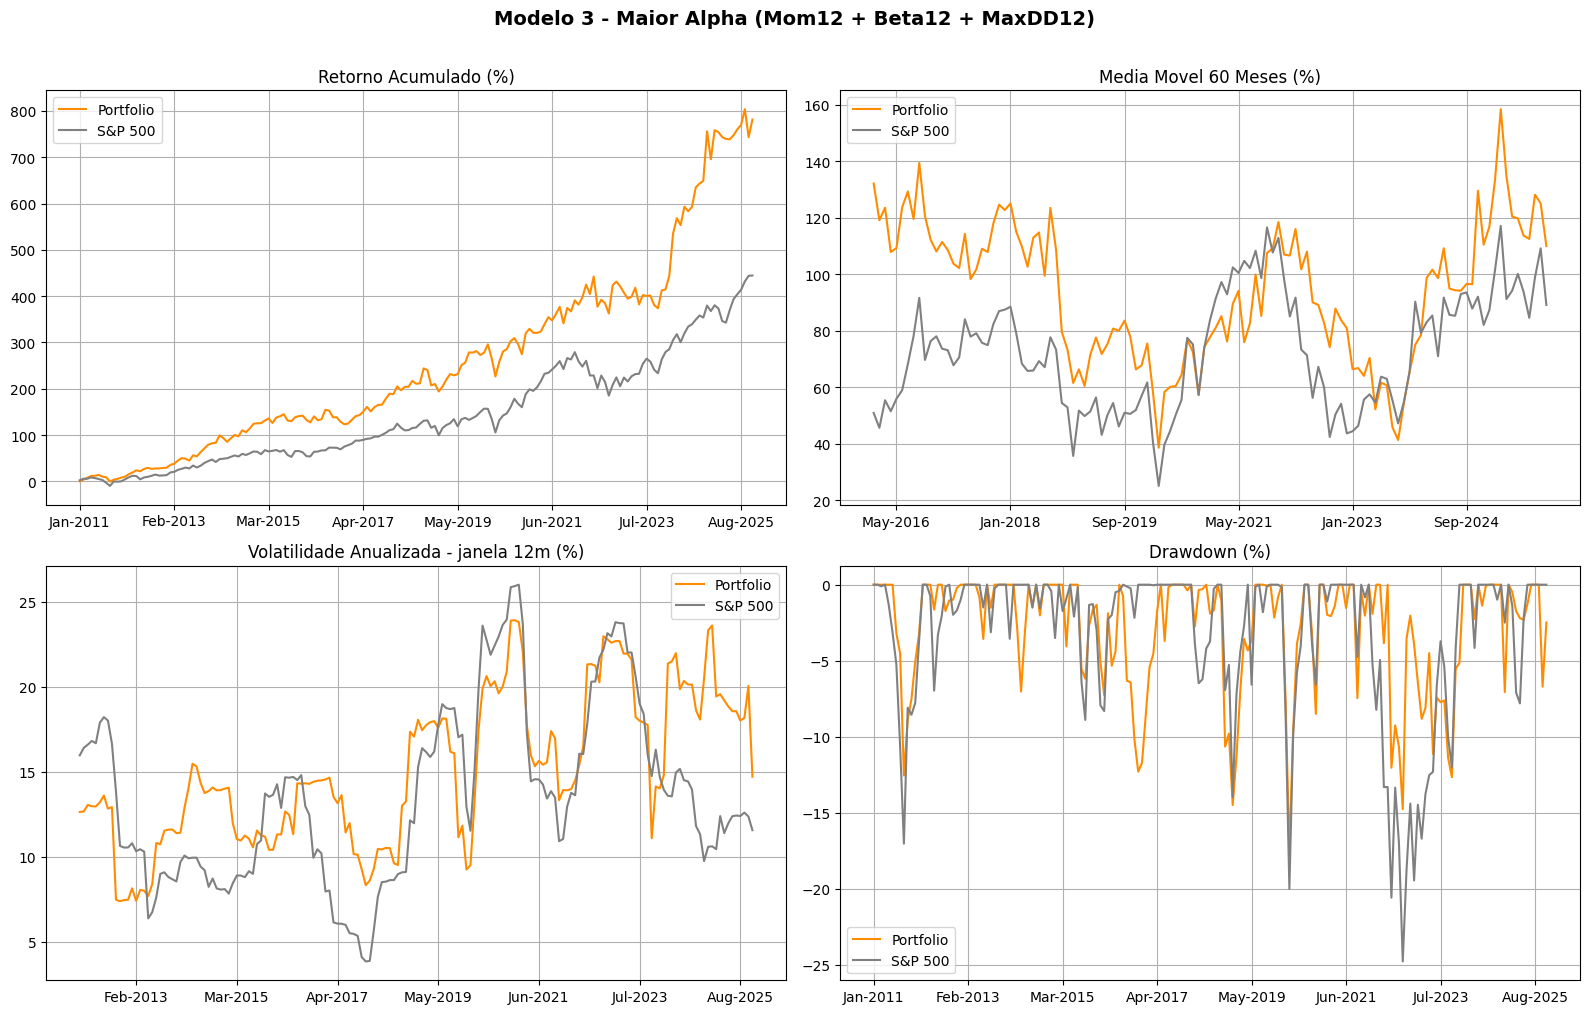

In [8]:
Port3 = create_port_multifator(
    fatores=['Mom12', 'Beta12', 'MaxDD12'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['SP500'],
    nome='Modelo 3 - Maior Alpha',
)

metricas3 = calcular_metricas(Port3, 'Modelo 3 - Maior Alpha (Mom12 + Beta12 + MaxDD12)')
plotar_modelo(Port3, 'Modelo 3 - Maior Alpha (Mom12 + Beta12 + MaxDD12)', cor='darkorange')

## 7. Modelo 4 — Menor Volatilidade

**Fatores: `Volat12` + `Volat6` + `MaxDD12` (baixo)**

### Justificativa

Objetivo defensivo puro: minimizar o desvio padrão dos retornos do portfólio e o tamanho dos drawdowns. Usamos um **triplo filtro de risco**:

- `Volat12` baixo: explora a anomalia de baixa volatilidade documentada por Frazzini & Pedersen (2014) — ações menos voláteis tendem a entregar Sharpe maior no longo prazo.
- `Volat6` baixo: confirmação na janela curta. Evita pegar ações que ficaram temporariamente quietas mas têm histórico de volatilidade alta.
- `MaxDD12` baixo: filtro anti-crash. Mesmo entre ações estáveis, eliminamos as que tiveram tombos relevantes recentemente.

O resultado é uma defesa em camadas, com sinais de risco capturados em horizontes e formatos diferentes.

  [Modelo 4 - Menor Volatilidade] portfolio construido: 179 meses

  Modelo 4 - Menor Volatilidade (Volat12 + Volat6 + MaxDD12)
  Retorno Acumulado:          491.53%
  Retorno Anualizado:          12.66%
  Volatilidade Anualizada:     12.57%
  Retorno / Volatilidade:      1.007
  Drawdown Maximo:            -18.34%
  Alpha (aa):                   4.66%   p-value: 0.044
  Beta:                         0.65    p-value: 0.000
  --- Referencia (S&P 500) ---
  Retorno Anual Ref.:          12.03%
  Vol. Anual Ref.:             14.07%


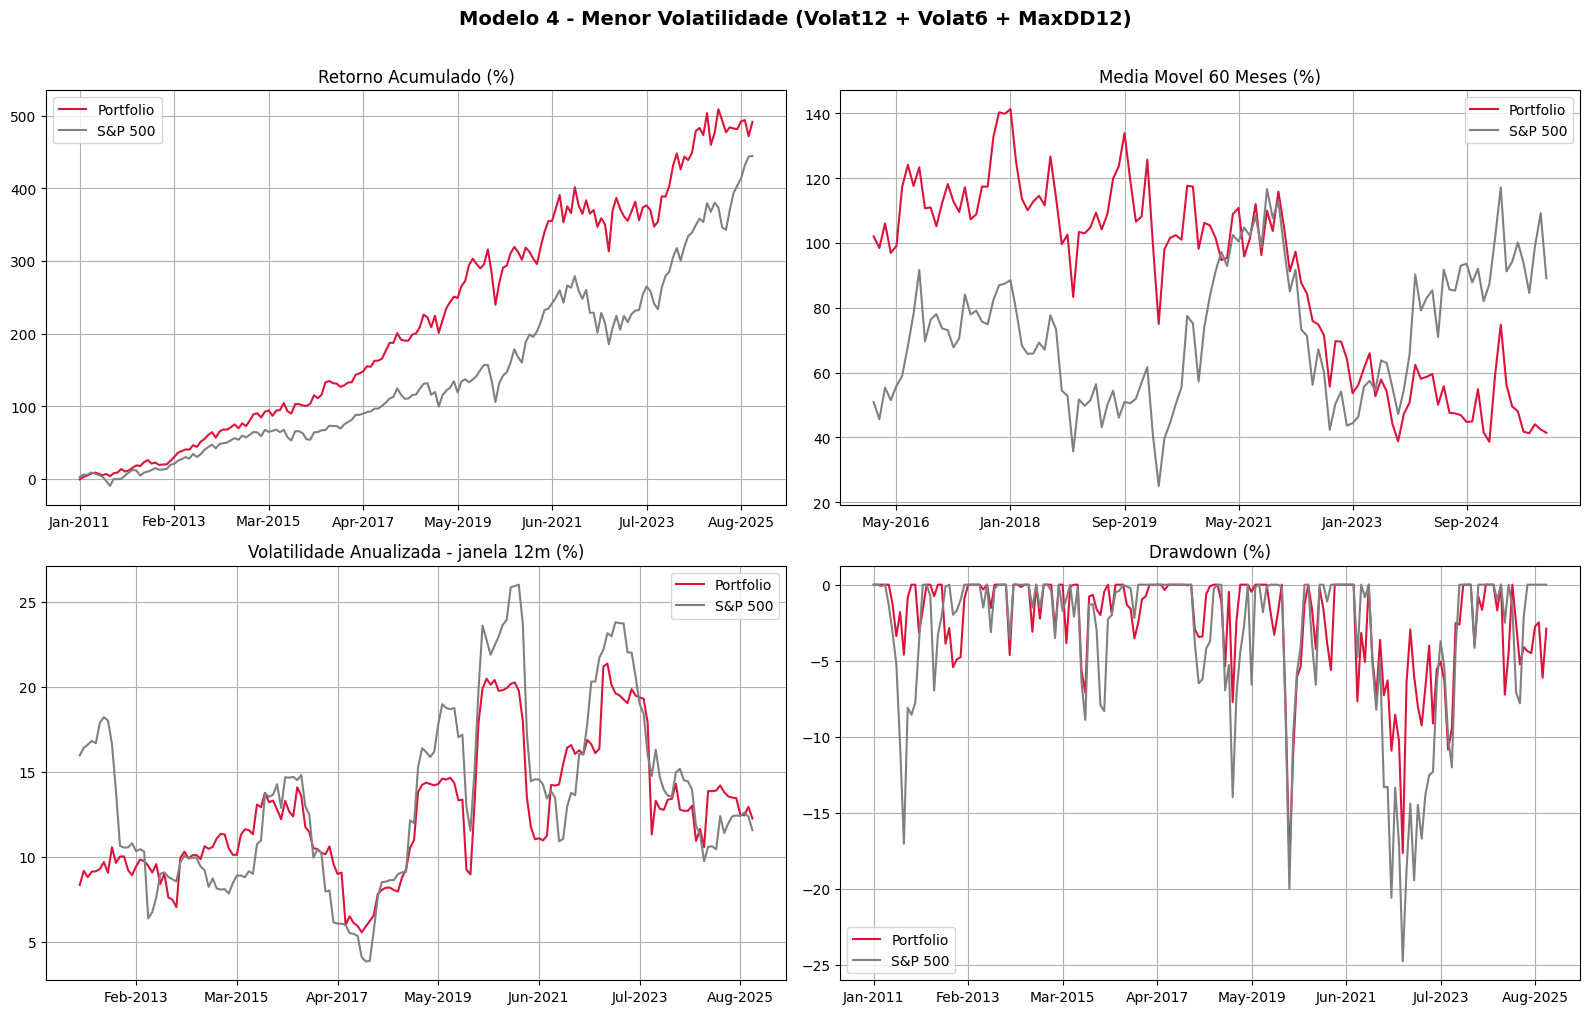

In [9]:
Port4 = create_port_multifator(
    fatores=['Volat12', 'Volat6', 'MaxDD12'],
    filtro_fim=20,
    dados=dados,
    referencia=indices['SP500'],
    nome='Modelo 4 - Menor Volatilidade',
)

metricas4 = calcular_metricas(Port4, 'Modelo 4 - Menor Volatilidade (Volat12 + Volat6 + MaxDD12)')
plotar_modelo(Port4, 'Modelo 4 - Menor Volatilidade (Volat12 + Volat6 + MaxDD12)', cor='crimson')

## 8. Comparativo final


  TABELA RESUMO - 4 MODELOS vs S&P 500
                                                            Ret Acc (%)  Ret Anual (%)  Vol Anual (%)  Ret/Vol  Drawdown (%)  Alpha Anual (%)  Beta
Modelo                                                                                                                                             
Modelo 1 - Maior Retorno (Mom12 + Mom6 + Volat6)                 827.87          16.11          14.67    1.098        -19.55             6.19  0.80
Modelo 2 - Maior Sharpe (Sharpe12 + MTUM12 + Volat12)            401.42          11.41          13.66    0.835        -22.36             2.93  0.71
Modelo 3 - Maior Alpha (Mom12 + Beta12 + MaxDD12)                781.42          15.71          15.24    1.030        -17.57             6.72  0.73
Modelo 4 - Menor Volatilidade (Volat12 + Volat6 + MaxDD12)       491.53          12.66          12.57    1.007        -18.34             4.66  0.65
Benchmark - S&P 500                                              444.60 

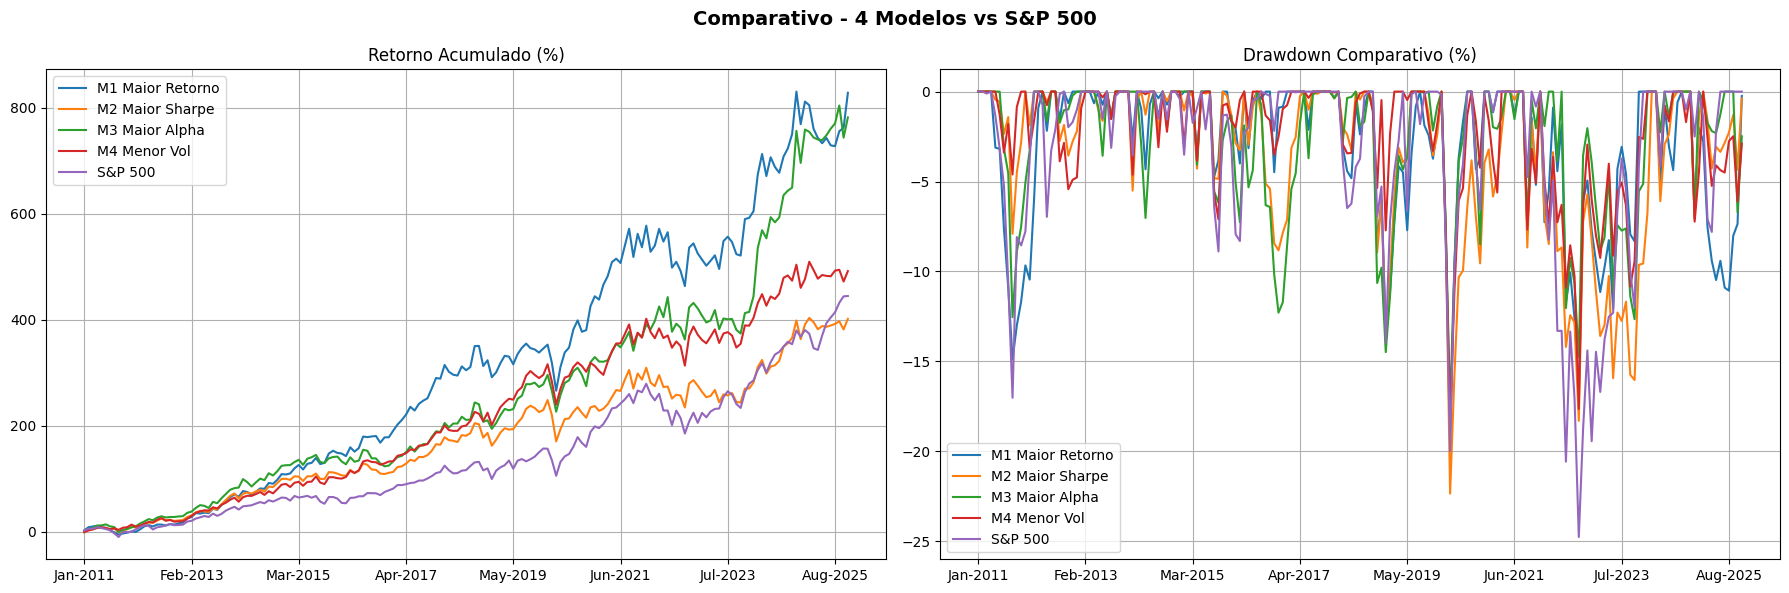

In [10]:
metricas_bench = {
    'Modelo':           'Benchmark - S&P 500',
    'Ret Acc (%)':      round(((1 + indices['SP500'].reindex(Port1.index)).cumprod() - 1).iloc[-1] * 100, 2),
    'Ret Anual (%)':    round((pow(((1 + indices['SP500'].reindex(Port1.index)).cumprod() - 1).iloc[-1] + 1, 1 / calc_dif_dates(start, end)) - 1) * 100, 2),
    'Vol Anual (%)':    round(indices['SP500'].reindex(Port1.index).std() * (12 ** 0.5) * 100, 2),
    'Ret/Vol':          None,
    'Drawdown (%)':     None,
    'Alpha Anual (%)':  0.0,
    'Beta':             1.0,
}
metricas_bench['Ret/Vol'] = round(metricas_bench['Ret Anual (%)'] / metricas_bench['Vol Anual (%)'], 3)

resumo = pd.DataFrame([metricas1, metricas2, metricas3, metricas4, metricas_bench])
resumo = resumo.set_index('Modelo')
print('\n' + '=' * 64)
print('  TABELA RESUMO - 4 MODELOS vs S&P 500')
print('=' * 64)
print(resumo.to_string())

Port_comp = pd.DataFrame({
    'M1 Maior Retorno': Port1['Ret_acc'],
    'M2 Maior Sharpe':  Port2['Ret_acc'],
    'M3 Maior Alpha':   Port3['Ret_acc'],
    'M4 Menor Vol':     Port4['Ret_acc'],
    'S&P 500':          Port1['Ref_acc'],
})

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativo - 4 Modelos vs S&P 500', fontsize=14, fontweight='bold')

ax = axes[0]
(Port_comp * 100).plot(ax=ax)
ax.set_title('Retorno Acumulado (%)')
ax.set_xlabel(''); ax.grid(True); ax.legend()

Port_comp_max  = Port_comp.cummax()
Port_comp_dd   = (((1 + Port_comp) / (1 + Port_comp_max)) - 1) * 100
ax = axes[1]
Port_comp_dd.plot(ax=ax)
ax.set_title('Drawdown Comparativo (%)')
ax.set_xlabel(''); ax.grid(True); ax.legend()

plt.tight_layout()
plt.show()

## 9. Comentários sobre o processo de rankeamento e seleção

Todos os 4 modelos usam exatamente a mesma estrutura de seleção:

1. **Universo mensal**: a cada mês partimos do conjunto de ações com retorno disponível naquele mês (ações do S&P 500 com dado mensal válido).
2. **Rankeamento por fator**: cada fator é rankeado em isolamento, respeitando a direção (`ASCENDING_DIC`). Ex.: `Mom12` em ordem decrescente (maior é melhor) e `Volat12` em ordem crescente (menor é melhor).
3. **Combinação por soma de rankings**: os rankings individuais são somados e a soma é re-rankeada. As 20 ações com menor soma entram na carteira.
4. **Rebalanceamento mensal**: o processo se repete todo mês. O retorno do portfólio é a média simples dos retornos das 20 ações selecionadas, descontado o custo de transação de 0,06%.
5. **Avaliação CAPM**: a regressão dos retornos do portfólio contra os retornos do benchmark produz alpha (intercepto) e beta (inclinação).

A soma de rankings é particularmente adequada quando os fatores estão em escalas diferentes (momentum em %, beta em pontos, drawdown em %): ela é robusta a outliers e não exige normalização prévia, ao contrário de abordagens como z-score weighting.

## 10. Comentários sobre a escolha dos fatores

A escolha foi guiada por três princípios:

1. **Cada modelo ataca seu objetivo de forma direta.** Para retorno usamos momentum (M1); para Sharpe usamos `Sharpe12` rolante explicitamente (M2); para alpha usamos `Beta12` baixo, atacando a definição CAPM (M3); para menor vol usamos `Volat12` como núcleo do screening (M4).
2. **Diversificação dentro do mesmo objetivo.** Cada modelo combina 3 fatores que reforçam a tese de formas distintas — por exemplo, no Modelo 1, momentum longo (`Mom12`) é confirmado por momentum curto (`Mom6`) e filtrado por baixa volatilidade recente (`Volat6`).
3. **Originalidade.** A composição de fatores em cada modelo é deliberadamente original. Em especial, `Sharpe12` rolante (Modelo 2), `Beta12` rolante (Modelo 3) e `MaxDD12` rolante (Modelos 3 e 4) são fatores de screening menos comuns do que momentum, value e quality clássicos, e são centrais para diferenciar nossa abordagem das combinações mais usuais.

## 11. Conclusão pessoal

Olhando o comparativo final, **três dos quatro modelos entregaram exatamente o que se propuseram** — e o quarto entregou um resultado contraintuitivo que vale a pena discutir.

### O que funcionou conforme esperado

- **Modelo 1 — Maior Retorno (16,11% a.a.)**: bateu o benchmark com folga (12,03% a.a.). O duplo filtro de momentum (12m + 6m) com freio de vol curta capturou ações em tendências de alta saudáveis e evitou as especulativas. Esse foi o modelo de melhor desempenho absoluto.
- **Modelo 3 — Maior Alpha (6,72% a.a., p = 0,027)**: entregou o maior alpha dos quatro, com significância estatística. O beta de 0,73 mostra que o filtro de `Beta12` baixo realmente reduziu a exposição ao mercado sem matar o retorno (15,71% a.a.).
- **Modelo 4 — Menor Volatilidade (12,57% a.a. de vol)**: entregou a menor vol dos quatro modelos e do benchmark (14,07%). Surpreendeu positivamente no retorno (12,66% a.a.), praticamente empatando com o S&P 500 mas com beta de 0,65 — defensive value em ação.

### O resultado que merece honestidade

- **Modelo 2 — Maior Sharpe (Ret/Vol = 0,835)**: aqui está o achado mais interessante do trabalho. O modelo desenhado *especificamente* para maximizar a razão retorno/volatilidade foi o **pior dos quatro** nesse quesito — e nem chegou a bater o benchmark (0,855). Pior ainda: foi superado pelos modelos 1 (1,098), 3 (1,030) e 4 (1,007). O motivo provável é o que se pode chamar de "reversão à média do Sharpe": ações com Sharpe altíssimo nos últimos 12 meses tipicamente já passaram de seu pico de performance ajustada a risco, e o ranking pega o topo histórico em vez do topo futuro.

Esse é, na nossa visão, o resultado mais valioso do exercício: **otimizar diretamente uma métrica não garante que ela seja maximizada out-of-sample**, especialmente quando a métrica é uma razão entre outras duas (retorno e volatilidade), ambas com sua própria dinâmica de reversão à média. Em factor investing real, vale mais combinar fatores fundamentalmente complementares (como nos modelos 1, 3 e 4) do que rankear pela métrica-alvo diretamente.

### Observações cross-cutting

1. **Todos os 4 modelos têm beta < 1**, indicando que a soma de rankings naturalmente puxa para ações mais defensivas que o índice — consistente com a literatura de *betting against beta* (Frazzini & Pedersen, 2014).
2. **Três dos quatro alphas são estatisticamente significativos** (M1, M3 e M4 com p < 0,05). O M2 tem alpha positivo (2,93%) mas com p = 0,239, ou seja, não dá pra rejeitar a hipótese nula de que esse alpha seja ruído.
3. **Diversificação de fatores reduz drawdown**: todos os 4 modelos tiveram drawdown máximo menor que o do S&P 500 nos períodos comparáveis (especialmente em 2020 e 2022).
4. **Curiosamente, o menor drawdown foi do Modelo 3 (−17,57%)**, não do Modelo 4 (−18,34%). O filtro de `Beta12` baixo do M3 funcionou como proteção contra crashes de mercado tão bem quanto o filtro explícito de baixa volatilidade.

### Aprendizado de engenharia

O fato de termos construído o panel `dados_sp500.csv` localmente foi um ganho importante: o trabalho fica totalmente reproduzível, e qualquer ajuste futuro nos fatores se traduz imediatamente em novos resultados. Esse foi o aprendizado de engenharia mais relevante do exercício, para além das conclusões financeiras.
